# NB01: 서울시 행정경계 추출 및 행정동코드 매핑

**목적**: 전국 행정동 경계 shapefile에서 성남시 50개 동을 추출하고, CSV 데이터와 조인 가능한 행정동코드 crosswalk 생성

**입력**: `00_data/tb_etl_tp_admstr_zone_lgldong_bndry"/"admstr_zone_lgldong_bndry_24.shp` (EPSG:5179, 전국 3,559개 동)  
**출력**: `processed/seongnam_boundary.gpkg` (성남시 50개 동, EPSG:4326, 행정동코드 매핑 포함)

In [13]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

BASE = Path(r"E:\서울시데이터경진대회\Aero-Logic-Seoul")
RAW = BASE / "00_data"
OUT = BASE / "processed"

## 1. 서울시 행정동 경계 추출

shapefile의 통계청코드 체계:
- `31021xxx` = 수정구, `31022xxx` = 중원구, `31023xxx` = 분당구

In [17]:
# 1. 전국 행정동 경계 로드
gdf_all = gpd.read_file(RAW / "BND_ADM_DONG_PG" / "BND_ADM_DONG_PG.shp", encoding="cp949")
print(f"전국 행정동 수: {len(gdf_all)}, CRS: {gdf_all.crs}")

# 2. 문자열 변환 (다시 ADM_CD 사용!)
gdf_all["ADM_CD"] = gdf_all["ADM_CD"].astype(str)

# 3. 서울만 필터 (prefix = "11")
seoul = gdf_all[gdf_all["ADM_CD"].str.startswith("11")].copy()
print(f"서울 행정동 수: {len(seoul)}")

# 4. 구 코드 추출 (앞 5자리)
seoul["SIG_CD"] = seoul["ADM_CD"].str[:5]

# 💡 통계청(SGIS) 기준 서울시 구 코드 맵핑
SEOUL_GU_MAP_SGIS = {
    "11010": "종로구", "11020": "중구", "11030": "용산구",
    "11040": "성동구", "11050": "광진구", "11060": "동대문구",
    "11070": "중랑구", "11080": "성북구", "11090": "강북구",
    "11100": "도봉구", "11110": "노원구", "11120": "은평구",
    "11130": "서대문구", "11140": "마포구", "11150": "양천구",
    "11160": "강서구", "11170": "구로구", "11180": "금천구",
    "11190": "영등포구", "11200": "동작구", "11210": "관악구",
    "11220": "서초구", "11230": "강남구", "11240": "송파구", "11250": "강동구",
}

# 맵핑 적용
seoul["GU_NM"] = seoul["SIG_CD"].map(SEOUL_GU_MAP_SGIS)

# 다시 확인
seoul[["ADM_CD", "SIG_CD", "GU_NM", "ADM_NM"]].sort_values("ADM_CD").head(10)

# 확인
print("\n👀 서울시 행정동 데이터 샘플:")
display(seoul[["ADM_CD", "SIG_CD", "GU_NM", "ADM_NM"]].sort_values("ADM_CD").head(10))

전국 행정동 수: 3559, CRS: EPSG:5186
서울 행정동 수: 426

👀 서울시 행정동 데이터 샘플:


,ADM_CD,SIG_CD,GU_NM,ADM_NM
0,11010530,11010,종로구,사직동
1,11010540,11010,종로구,삼청동
2,11010550,11010,종로구,부암동
3,11010560,11010,종로구,평창동
4,11010570,11010,종로구,무악동
5,11010580,11010,종로구,교남동
6,11010600,11010,종로구,가회동
7,11010610,11010,종로구,종로1·2·3·4가동
8,11010630,11010,종로구,종로5·6가동
9,11010640,11010,종로구,이화동


## 2. 행정동코드 Crosswalk 생성

CSV 데이터의 행정동코드 체계: `41131xxx`(수정구), `41133xxx`(중원구), `41135xxx`(분당구)  
동 이름(ADM_NM)으로 매칭하여 crosswalk 테이블 생성

In [39]:
import glob
import pandas as pd
import geopandas as gpd

# ==========================================
# 1. Shapefile 로드 (통계청 코드) 및 GU_NM(구 이름) 생성
# ==========================================
gdf_all = gpd.read_file(RAW / "BND_ADM_DONG_PG" / "BND_ADM_DONG_PG.shp", encoding="cp949")
gdf_all["ADM_CD"] = gdf_all["ADM_CD"].astype(str)
seoul = gdf_all[gdf_all["ADM_CD"].str.startswith("11")].copy()

# 💡 누락되었던 구 이름(GU_NM) 생성 코드 추가
seoul["SIG_CD"] = seoul["ADM_CD"].str[:5]
SEOUL_GU_MAP_SGIS = {
    "11010": "종로구", "11020": "중구", "11030": "용산구",
    "11040": "성동구", "11050": "광진구", "11060": "동대문구",
    "11070": "중랑구", "11080": "성북구", "11090": "강북구",
    "11100": "도봉구", "11110": "노원구", "11120": "은평구",
    "11130": "서대문구", "11140": "마포구", "11150": "양천구",
    "11160": "강서구", "11170": "구로구", "11180": "금천구",
    "11190": "영등포구", "11200": "동작구", "11210": "관악구",
    "11220": "서초구", "11230": "강남구", "11240": "송파구", "11250": "강동구",
}
seoul["GU_NM"] = seoul["SIG_CD"].map(SEOUL_GU_MAP_SGIS)

# ==========================================
# 2. 유동인구 CSV 로드 및 행정동코드 추출 (행안부 코드)
# ==========================================
fp_files = sorted(glob.glob(str(RAW / "LOCAL__*" / "*.csv")))
df_fp = pd.read_csv(fp_files[0], index_col=False) 

csv_codes = (
    df_fp[["행정동코드"]]
    .drop_duplicates()
    .sort_values("행정동코드")
    .reset_index(drop=True)
)
csv_codes["행정동코드"] = csv_codes["행정동코드"].astype(str)

# ==========================================
# 3. 깃허브에서 매핑 테이블 로드 및 자릿수 교정
# ==========================================
print("🌐 매핑 테이블 가져오는 중...")
github_url = "https://raw.githubusercontent.com/vuski/admdongkor/master/ver20230101/HangJeongDong_ver20230101.geojson"
gdf_map = gpd.read_file(github_url)
mapping_table = gdf_map[['adm_cd', 'adm_cd2', 'adm_nm']].copy()

mapping_table['SGIS_CD'] = mapping_table['adm_cd'].astype(str)
mapping_table['SGIS_CD'] = mapping_table['SGIS_CD'].apply(lambda x: x + '0' if len(x) == 7 else x)
mapping_table['MOIS_CD'] = mapping_table['adm_cd2'].astype(str).str[:8]

seoul_map = mapping_table[mapping_table['SGIS_CD'].str.startswith('11')].copy()

# ==========================================
# 4. 최종 3단 조인 (Merge)
# ==========================================
step1_merged = seoul.merge(
    seoul_map, 
    left_on="ADM_CD",     
    right_on="SGIS_CD",   
    how="inner"
)

final_df = step1_merged.merge(
    csv_codes,
    left_on="MOIS_CD",    
    right_on="행정동코드", 
    how="inner"
)

# ==========================================
# 5. 결과 양식 정리 및 출력
# ==========================================
final_output = final_df.rename(columns={
    'ADM_CD': 'SHP_ADM_CD',    
    'adm_nm': 'DONG_NM',       
    'GU_NM': 'GU_NM',          
    '행정동코드': 'CSV_ADMI_CD'  
})

crosswalk = final_output[['SHP_ADM_CD', 'DONG_NM', 'GU_NM', 'CSV_ADMI_CD']]

🌐 매핑 테이블 가져오는 중...


In [41]:
crosswalk['DONG_NM'] = crosswalk['DONG_NM'].str.split().str[-1]
crosswalk = crosswalk.sort_values('SHP_ADM_CD').reset_index(drop=True)
crosswalk["CSV_ADMI_CD"] = crosswalk["CSV_ADMI_CD"].astype(int)

print(f"✅ 최종 매칭 결과 (총 {len(final_output)}건):")
display(crosswalk.head(10))

✅ 최종 매칭 결과 (총 414건):


,SHP_ADM_CD,DONG_NM,GU_NM,CSV_ADMI_CD
0,11010530,사직동,종로구,11110530
1,11010540,삼청동,종로구,11110540
2,11010550,부암동,종로구,11110550
3,11010560,평창동,종로구,11110560
4,11010570,무악동,종로구,11110570
5,11010580,교남동,종로구,11110580
6,11010600,가회동,종로구,11110600
7,11010610,종로1·2·3·4가동,종로구,11110615
8,11010630,종로5·6가동,종로구,11110630
9,11010640,이화동,종로구,11110640


## 3. Crosswalk을 경계 GeoDataFrame에 병합 & CRS 변환

In [42]:
# crosswalk을 seongnam GeoDataFrame에 병합
seoul = seoul.rename(columns={"ADM_CD": "SHP_ADM_CD"})
seoul = seoul.merge(
    crosswalk[["SHP_ADM_CD", "CSV_ADMI_CD"]],
    on="SHP_ADM_CD",
    how="left",
)

# WGS84 변환 (Tableau & 웹 지도용)
seoul_4326 = seoul.to_crs(epsg=4326)
print(f"CRS 변환 완료: {seoul_4326.crs}")
print(f"컬럼: {seoul_4326.columns.tolist()}")
seoul_4326[["SHP_ADM_CD", "CSV_ADMI_CD", "GU_NM", "ADM_NM"]].head()

CRS 변환 완료: EPSG:4326
컬럼: ['BASE_DATE', 'SHP_ADM_CD', 'ADM_NM', 'geometry', 'SIG_CD', 'GU_NM', 'CSV_ADMI_CD']


,SHP_ADM_CD,CSV_ADMI_CD,GU_NM,ADM_NM
0,11010530,11110530.0,종로구,사직동
1,11010540,11110540.0,종로구,삼청동
2,11010550,11110550.0,종로구,부암동
3,11010560,11110560.0,종로구,평창동
4,11010570,11110570.0,종로구,무악동


## 4. 성남시 전체 경계(Dissolved) 생성 + Bounding Box 계산

In [44]:
# 서울시 전체 경계 (동 경계 합치기)
city_boundary = seoul_4326.dissolve()
city_boundary["NAME"] = "서울시"
print(f"서울시 전체 경계 생성 (1 polygon)")

# Bounding box (EPSG:4326 / EPSG:5179 양쪽 계산)
bounds_4326 = seoul_4326.total_bounds  # (minx, miny, maxx, maxy)
bounds_5179 = seoul.total_bounds
print(f"\nBounds (EPSG:4326): lon {bounds_4326[0]:.4f}~{bounds_4326[2]:.4f}, lat {bounds_4326[1]:.4f}~{bounds_4326[3]:.4f}")
print(f"Bounds (EPSG:5179): x {bounds_5179[0]:.0f}~{bounds_5179[2]:.0f}, y {bounds_5179[1]:.0f}~{bounds_5179[3]:.0f}")
print(f"\n→ NB02에서 건물 shapefile 읽을 때 bbox 필터에 사용: bbox=({bounds_5179[0]:.0f}, {bounds_5179[1]:.0f}, {bounds_5179[2]:.0f}, {bounds_5179[3]:.0f})")

서울시 전체 경계 생성 (1 polygon)

Bounds (EPSG:4326): lon 126.7645~127.1838, lat 37.4283~37.7015
Bounds (EPSG:5179): x 179190~216242, y 536547~566864

→ NB02에서 건물 shapefile 읽을 때 bbox 필터에 사용: bbox=(179190, 536547, 216242, 566864)


## 5. 시각적 검증

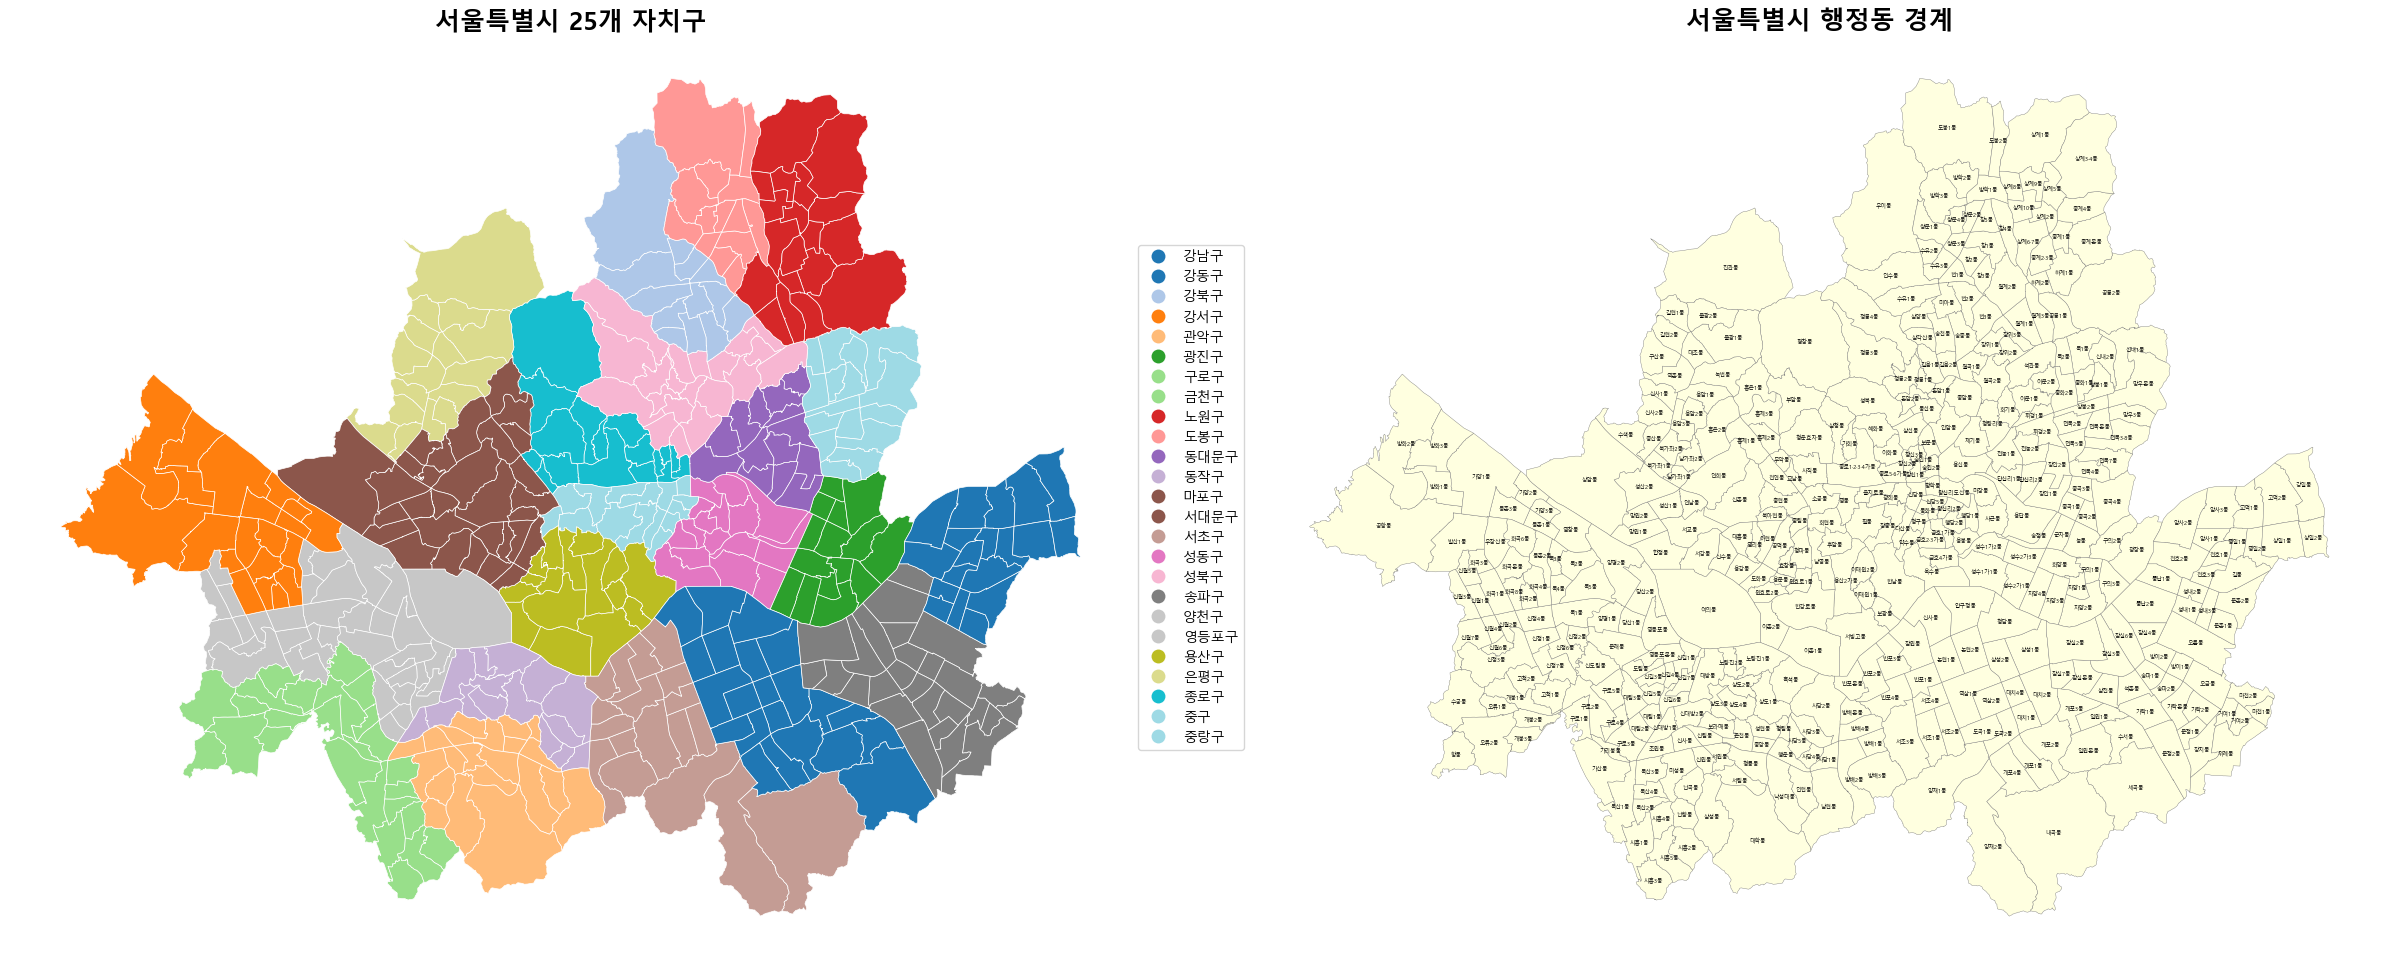

In [47]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 💡 서울은 동이 많아서 도화지(figsize)를 훨씬 넓게 펴주는 것이 좋습니다.
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# ==========================================
# 왼쪽: 자치구별 색상 (25개 구)
# ==========================================
# GeoPandas의 column 기능을 쓰면 for문 없이도 구별로 다른 색을 칠할 수 있습니다.
seoul_4326.plot(
    ax=axes[0], 
    column="GU_NM",      # 기준 컬럼: 구 이름
    cmap="tab20",        # 20가지 이상의 색상이 있는 컬러맵 (tab20, Set3 등)
    edgecolor="white", 
    linewidth=0.5, 
    legend=True,
    # 범례(Legend)가 지도와 겹치지 않게 바깥으로 빼줍니다.
    legend_kwds={'fontsize': 10, 'loc': 'center left', 'bbox_to_anchor': (1, 0.5)}
)
axes[0].set_title("서울특별시 25개 자치구", fontsize=18, fontweight="bold")
axes[0].set_axis_off()

# ==========================================
# 오른쪽: 행정동별 경계 + 라벨 (426개 동)
# ==========================================
seoul_4326.plot(ax=axes[1], edgecolor="gray", linewidth=0.3, color="lightyellow")

for _, row in seoul_4326.iterrows():
    centroid = row.geometry.centroid
    axes[1].annotate(
        text=row["ADM_NM"],  # 💡 만약 동 이름 컬럼이 ADM_NM이라면 이걸로 바꿔주세요!
        xy=(centroid.x, centroid.y),
        fontsize=4,           # 🚨 서울은 동이 너무 많아서 글씨를 4~5 수준으로 줄여야 덜 겹칩니다.
        ha="center", 
        va="center"
    )
axes[1].set_title("서울특별시 행정동 경계", fontsize=18, fontweight="bold")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 6. 저장

In [48]:
# 행정동 경계 (EPSG:4326, CSV 행정동코드 포함)
seoul_4326.to_file(OUT / "seoul_boundary.gpkg", layer="dong", driver="GPKG")

# 서울시 전체 경계 (dissolved)
city_boundary.to_file(OUT / "seoul_boundary.gpkg", layer="city", driver="GPKG")

# 행정동 경계 (EPSG:5179, 거리 계산용)
seoul.to_file(OUT / "seoul_boundary.gpkg", layer="dong_5179", driver="GPKG")

# Crosswalk CSV (다른 노트북에서 참조용)
crosswalk_df = crosswalk[["SHP_ADM_CD", "CSV_ADMI_CD", "GU_NM", "DONG_NM"]].copy()
crosswalk_df.to_csv(OUT / "admin_code_crosswalk.csv", index=False, encoding="utf-8-sig")

print("저장 완료:")
print(f"  - {OUT / 'seoul_boundary.gpkg'} (3 layers: dong, city, dong_5179)")
print(f"  - {OUT / 'admin_code_crosswalk.csv'}")
print(f"\n서울시 Bounds (EPSG:5179) for NB02 bbox filter:")
print(f"  bbox=({bounds_5179[0]:.0f}, {bounds_5179[1]:.0f}, {bounds_5179[2]:.0f}, {bounds_5179[3]:.0f})")

저장 완료:
  - E:\서울시데이터경진대회\Aero-Logic-Seoul\processed\seoul_boundary.gpkg (3 layers: dong, city, dong_5179)
  - E:\서울시데이터경진대회\Aero-Logic-Seoul\processed\admin_code_crosswalk.csv

서울시 Bounds (EPSG:5179) for NB02 bbox filter:
  bbox=(179190, 536547, 216242, 566864)
